# 15 · Diagnósticos de Regresión

Después de ajustar un modelo, debemos **diagnosticar** si se comporta bien. Este notebook es un resumen general — cada tema tiene su notebook dedicado.

| Tema | Notebook | Qué detecta |
|------|----------|-------------|
| Outliers | `15-1-outliers` | Observaciones con residuos inusuales |
| Leverage | `15-2-leverage` | Observaciones con predictores extremos |
| Valores influyentes | `15-3-influential-values` | Observaciones que distorsionan el modelo |

In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("../data/housing.csv")

predictors = [
    "square_meters",
    "bedrooms",
    "bathrooms",
    "build_quality",
    "age",
    "distance_to_center_km",
    "has_garage",
]

X = df[predictors]
y = df["price"]
n, p = X.shape

ols = sm.OLS(y, sm.add_constant(X)).fit()
influence = ols.get_influence()

y_pred = ols.fittedvalues
e = ols.resid
std_resid = influence.resid_studentized_internal
leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]

print(f"R² = {ols.rsquared:.4f}, n = {n}, p = {p}")

R² = 0.8713, n = 100, p = 7


## 1 · Vista Rápida: Outliers, Leverage e Influencia

Tres conceptos distintos pero relacionados:

- **Outlier**: residuo grande ($|r_i| > 2$) → ver `15-1-outliers`
- **Leverage**: predictores extremos ($h_{ii} > 2(p+1)/n$) → ver `15-2-leverage`
- **Influencia**: outlier + leverage combinados (Cook's $D > 4/n$) → ver `15-3-influential-values`

In [6]:
lev_threshold = 2 * (p + 1) / n
cook_threshold = 4 / n

summary = pd.DataFrame(
    {
        "std_resid": std_resid.round(2),
        "leverage": leverage.round(4),
        "cooks_d": cooks_d.round(4),
        "outlier?": np.abs(std_resid) > 2,
        "high_leverage?": leverage > lev_threshold,
        "influential?": cooks_d > cook_threshold,
    }
)

print(f"Outliers (|r|>2):       {summary['outlier?'].sum()}")
print(f"Alto leverage:          {summary['high_leverage?'].sum()}")
print(f"Influyentes (Cook>4/n): {summary['influential?'].sum()}")

# Mostrar solo los problemáticos
problematic = summary[
    summary["outlier?"] | summary["high_leverage?"] | summary["influential?"]
]
problematic

Outliers (|r|>2):       2
Alto leverage:          2
Influyentes (Cook>4/n): 4


,std_resid,leverage,cooks_d,outlier?,high_leverage?,influential?
9,2.64,0.0335,0.0303,True,False,False
12,2.53,0.0899,0.0791,True,False,True
14,1.60,0.1475,0.0557,False,False,True
31,-1.79,0.0973,0.0432,False,False,True
44,1.36,0.1625,0.0446,False,True,True
81,-1.08,0.1932,0.0349,False,True,False


## 2 · Residuos No Normales

La regresión asume residuos aproximadamente normales. Verificamos con QQ plot y Shapiro-Wilk.

> 👈 Desviaciones moderadas no afectan las predicciones, pero sí los intervalos de confianza.

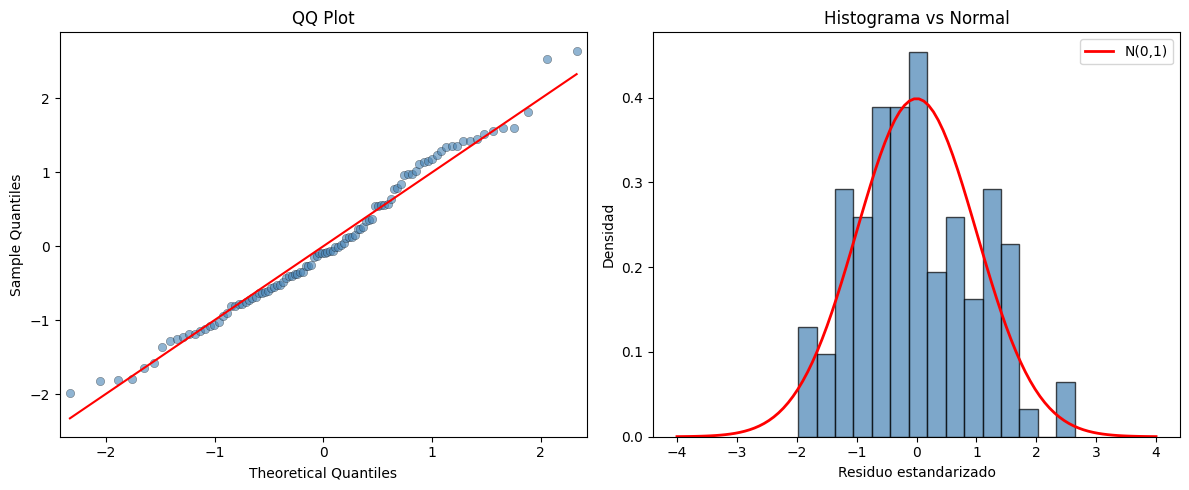

Shapiro-Wilk: W=0.9815, p=0.1735 ✅ No podemos rechazar normalidad


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
sm.qqplot(
    std_resid,
    line="s",
    ax=ax,
    markerfacecolor="steelblue",
    markeredgecolor="k",
    markeredgewidth=0.3,
    alpha=0.6,
)
ax.set_title("QQ Plot")

ax = axes[1]
ax.hist(
    std_resid, bins=15, color="steelblue", edgecolor="black", density=True, alpha=0.7
)
x_norm = np.linspace(-4, 4, 100)
ax.plot(x_norm, stats.norm.pdf(x_norm), "r-", linewidth=2, label="N(0,1)")
ax.set_xlabel("Residuo estandarizado")
ax.set_ylabel("Densidad")
ax.set_title("Histograma vs Normal")
ax.legend()

plt.tight_layout()
plt.show()

W, p_value = stats.shapiro(e)
emoji = "✅" if p_value > 0.05 else "🚨"
result = "No podemos rechazar normalidad" if p_value > 0.05 else "Residuos no normales"
print(f"Shapiro-Wilk: W={W:.4f}, p={p_value:.4f} {emoji} {result}")

## 3 · Heterocedasticidad

**Homocedasticidad** = varianza constante de los residuos. Si la varianza cambia con $\hat{y}$ (forma de embudo), los errores estándar no son confiables.

- **Residuos vs Fitted**: buscar patrón de embudo
- **Scale-Location**: $\sqrt{|r_i|}$ vs $\hat{y}$ — si la tendencia sube, la varianza crece

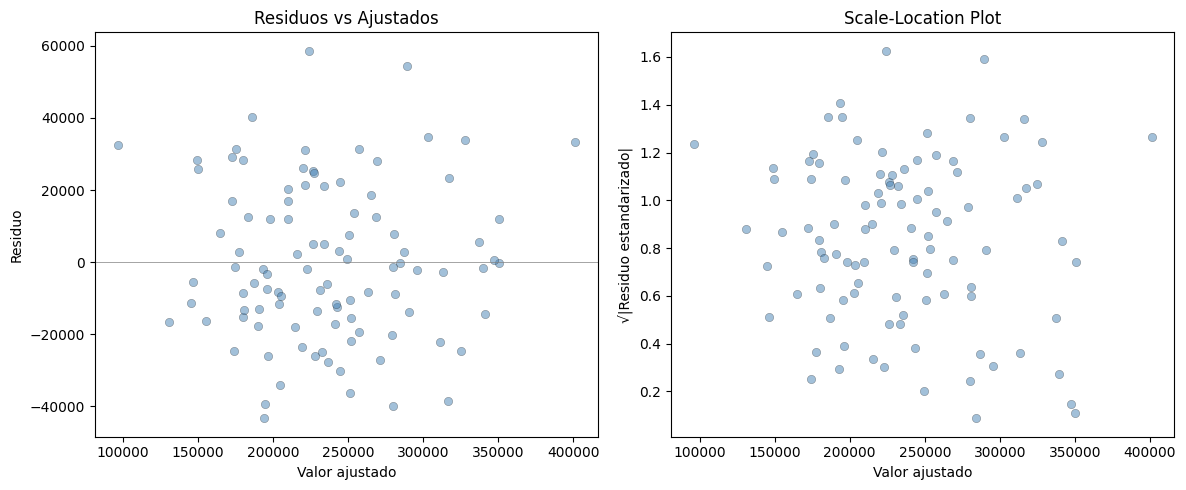

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sqrt_abs_std = np.sqrt(np.abs(std_resid))

ax = axes[0]
ax.scatter(y_pred, e, color="steelblue", alpha=0.5, edgecolors="k", linewidth=0.3)
ax.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)
ax.set_xlabel("Valor ajustado")
ax.set_ylabel("Residuo")
ax.set_title("Residuos vs Ajustados")

ax = axes[1]
ax.scatter(
    y_pred, sqrt_abs_std, color="steelblue", alpha=0.5, edgecolors="k", linewidth=0.3
)
ax.set_xlabel("Valor ajustado")
ax.set_ylabel("√|Residuo estandarizado|")
ax.set_title("Scale-Location Plot")

plt.tight_layout()
plt.show()

## 4 · Residuos Parciales

Revelan la relación entre cada predictor y la respuesta, controlando por los demás:

$$\text{Residuo parcial}_j = e + \hat{\beta}_j \cdot x_j$$

Si hay curvatura → el modelo necesita un término no lineal para ese predictor.

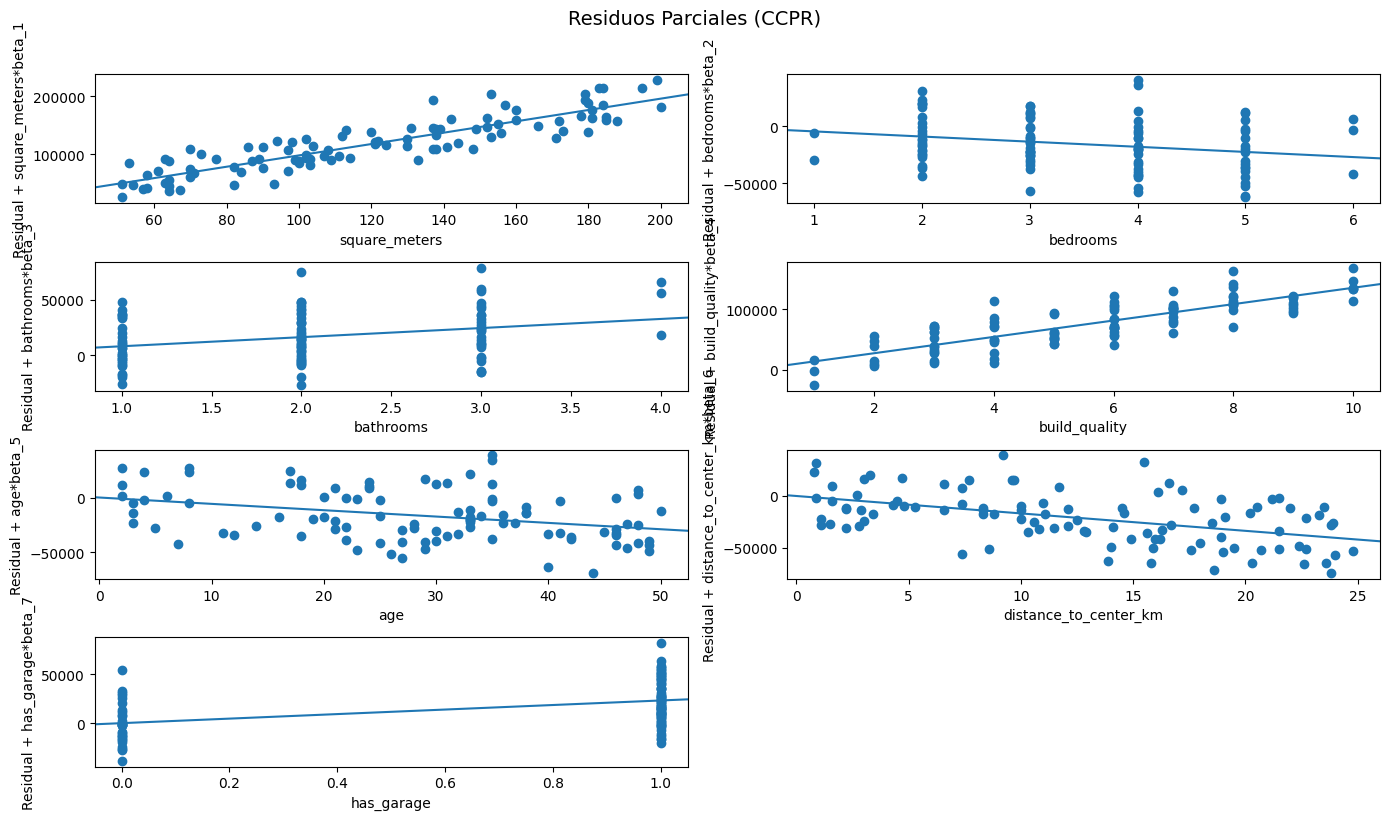

In [9]:
fig = plt.figure(figsize=(14, 8))
sm.graphics.plot_ccpr_grid(ols, exog_idx=list(range(1, p + 1)), fig=fig)
fig.suptitle("Residuos Parciales (CCPR)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5 · Panel Diagnóstico 2×2

El equivalente a `plot(model)` en R:

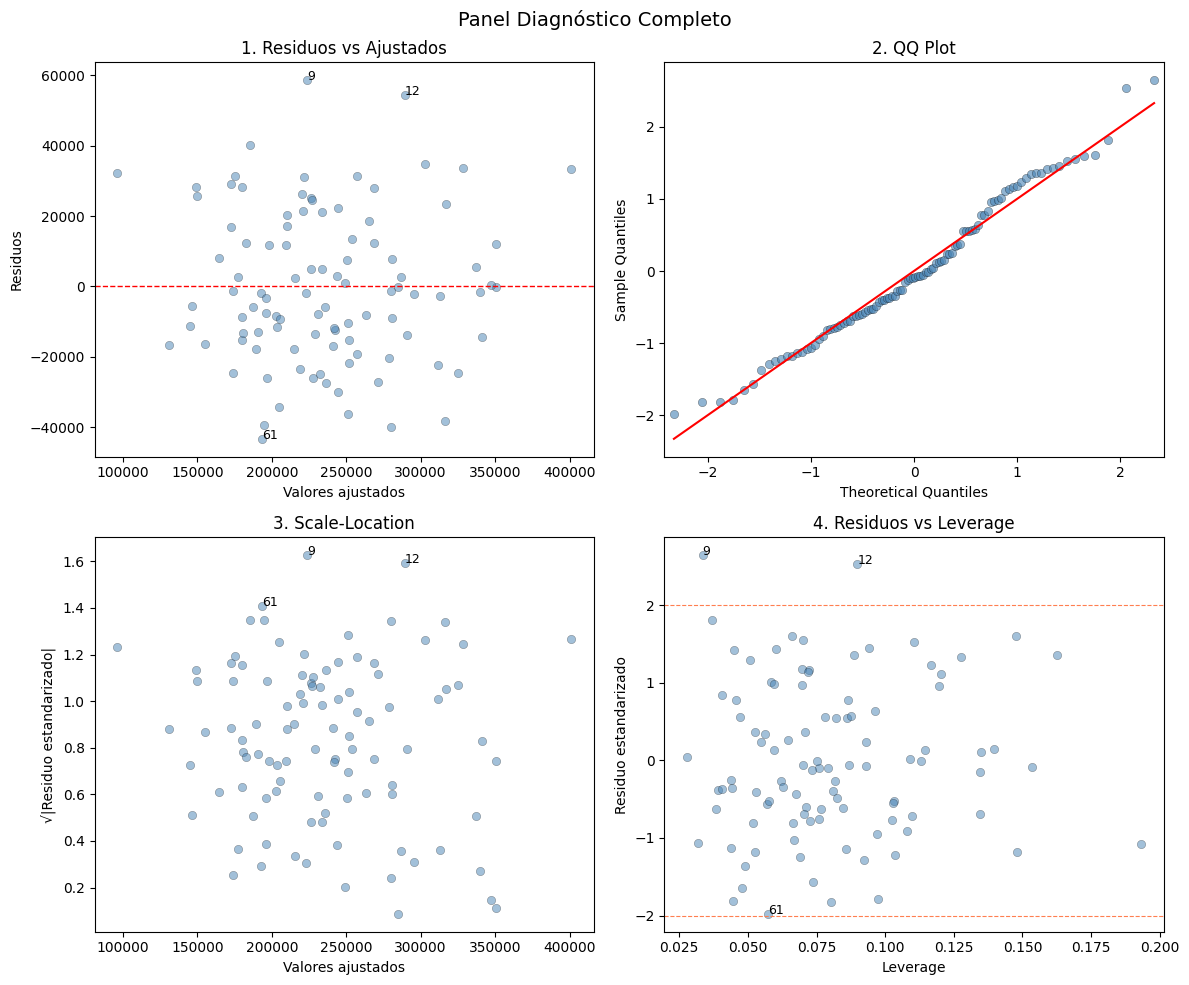

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
top3 = np.argsort(np.abs(std_resid))[-3:][::-1]

# 1. Residuals vs Fitted
ax = axes[0, 0]
ax.scatter(y_pred, e, color="steelblue", alpha=0.5, edgecolors="k", linewidth=0.3)
ax.axhline(y=0, color="red", linestyle="--", linewidth=1)
for i in top3:
    ax.annotate(str(i), (y_pred[i], e[i]), fontsize=9)
ax.set_xlabel("Valores ajustados")
ax.set_ylabel("Residuos")
ax.set_title("1. Residuos vs Ajustados")

# 2. QQ Plot
ax = axes[0, 1]
sm.qqplot(
    std_resid,
    line="s",
    ax=ax,
    markerfacecolor="steelblue",
    markeredgecolor="k",
    markeredgewidth=0.3,
    alpha=0.6,
)
ax.set_title("2. QQ Plot")

# 3. Scale-Location
ax = axes[1, 0]
ax.scatter(
    y_pred, sqrt_abs_std, color="steelblue", alpha=0.5, edgecolors="k", linewidth=0.3
)
for i in top3:
    ax.annotate(str(i), (y_pred[i], sqrt_abs_std[i]), fontsize=9)
ax.set_xlabel("Valores ajustados")
ax.set_ylabel("√|Residuo estandarizado|")
ax.set_title("3. Scale-Location")

# 4. Residuals vs Leverage
ax = axes[1, 1]
ax.scatter(
    leverage, std_resid, color="steelblue", alpha=0.5, edgecolors="k", linewidth=0.3
)
ax.axhline(y=2, color="coral", linestyle="--", linewidth=0.8)
ax.axhline(y=-2, color="coral", linestyle="--", linewidth=0.8)
for i in top3:
    ax.annotate(str(i), (leverage[i], std_resid[i]), fontsize=9)
ax.set_xlabel("Leverage")
ax.set_ylabel("Residuo estandarizado")
ax.set_title("4. Residuos vs Leverage")

plt.suptitle("Panel Diagnóstico Completo", fontsize=14)
plt.tight_layout()
plt.show()

## 6 · Resumen

| Diagnóstico | Qué detecta | Umbral |
|---|---|---|
| Residuos estandarizados | Outliers | $|r_i| > 2$ |
| Leverage | Predictores extremos | $h_{ii} > 2(p+1)/n$ |
| Cook's Distance | Valores influyentes | $D_i > 4/n$ |
| QQ Plot + Shapiro-Wilk | No normalidad | $p < 0.05$ |
| Residuos vs Fitted | Heterocedasticidad | Patrón de embudo |
| Residuos parciales | No linealidad | Curvatura |

| Problema | Acción |
|----------|--------|
| 🚨 Outlier | Investigar, no eliminar automáticamente |
| 🚨 Influyente | Comparar modelo con y sin el punto |
| 🚨 No normalidad | Transformar $y$ (e.g., $\log$) |
| 🚨 Heterocedasticidad | Regresión ponderada o transformar $y$ |
| 🚨 No linealidad | Términos cuadráticos o transformaciones |